# Notebook 2: Data Cleaning & Exploratory Data Analysis

This notebook covers the **Data Cleaning & Preprocessing** pipeline:
1. Loading the raw scraped data
2. Cleaning and preprocessing the text
3. Exploratory Data Analysis (EDA) with documented reasoning
4. Saving a clean dataset ready for Sentiment, NER, Topic Modeling


## Section 1 — Install & Import Dependencies

Install and import all required libraries for this notebook upfront so the environment is fully configured before any data is touched.

In [1]:
# Install required libraries
!pip install pandas matplotlib seaborn nltk wordcloud -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK downloads
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

# Consistent plot style throughout notebook
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Section 2 — Load Raw Data

Load both CSV files produced in Notebook 1 (Data Scraping).  
- `comments.csv` — Rows of raw YouTube comments  
- `videos.csv` — 12 video metadata records  

In [15]:
# ── Load data ──────────────────────────────────────────────────────────────
comments_df = pd.read_csv('comments.csv.gz')
videos_df   = pd.read_csv('videos.csv')

print(f"Comments shape : {comments_df.shape}")
print(f"Videos shape   : {videos_df.shape}")
print()
print("─── Comments columns ───")
print(comments_df.dtypes)
print()
print("─── First 3 rows ───")
comments_df.head(3)

Comments shape : (56188, 7)
Videos shape   : (12, 5)

─── Comments columns ───
comment_id      object
video_id        object
author          object
published_at    object
like_count       int64
text            object
title           object
dtype: object

─── First 3 rows ───


,comment_id,video_id,author,published_at,like_count,text,title
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,@jadehannah916,2026-06-22T19:50:06Z,0,19:23 expiry dates have left the chat,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,@jadehannah916,2026-06-22T19:46:57Z,0,16:34 just work at a grocery store at this point,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,@Sevdalina-e2l,2026-06-22T11:08:51Z,0,19:40 this specific content made my heart blee...,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."


In [16]:
# Quick sanity check on videos
videos_df

,video_id,title,description,channel,published_at
0,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",#hannahalonzo #influencer #commentary \n\nI am...,Hannah Alonzo,2024-01-22T16:00:12Z
1,CPY4wg1X1Os,TOXIC “GLOW UP” CULTURE & EXTREME SELF-MAINTEN...,Get $5 off your next order through my link htt...,Hannah Alonzo,2025-03-24T14:30:06Z
2,mRhjFU77WUM,Is This the Worst Overconsumption Trend of All...,"We've come a long way since the iconic ""What's...",Kiki Chanel,2025-07-02T14:00:05Z
3,ZBLqQZ4JAPU,5 Things We Normalize and Overconsume Without ...,"In this video, I’m calling out the everyday th...",Susannah Friesen,2025-07-28T13:01:06Z
4,snEbiost_OQ,"Why we NEED TikTok's ""underconsumption core"" (...","The pendulum is SWINGING my friends, but this ...",Melanie Murphy,2024-10-16T16:21:01Z
5,hwsGZAmC1Bs,The Rise of Identity Consumerism,Head over to https://www.shortform.com/accordi...,According To Nicole,2026-02-22T15:01:13Z
6,FTlcMycU13E,dissecting tiktok's newest trend: underconsump...,talking about underconsumption on a platform b...,katie robinson,2024-07-25T18:30:19Z
7,kzn6HFgCAe0,TIKTOK’S BEAUTY OVERCONSUMPTION CRISIS IS OUT ...,Use code HANNAHALONZO130 to get $130 off acros...,Hannah Alonzo,2025-01-06T16:00:45Z
8,aw7ayuTZxi0,How America Got So Good At Buying Sh*t,Sign up and download Grammarly for FREE: http:...,How Money Works,2025-03-03T03:02:11Z
9,4pG-8XLLaE0,Consumerism is the Perfection of Slavery - Pro...,Clip taken from: \nhttps://www.youtube.com/wat...,Prof. Jiang Clips,2025-07-02T16:10:21Z


## Section 3 — Pre-Cleaning Data Audit

Audit the raw data to understand what problems exist before modifying it, directly informing which cleaning operations are necessary.

Check for:
- **Null / missing values** — empty comments cannot be analyzed
- **Duplicate comment IDs** — already removed in scraping, but we verify
- **Duplicate text** — identical comment text from different IDs (copy-paste spam)
- **Very short comments** — single characters or emoji-only offer no linguistic signal
- **Comment length distribution** — helps us set a minimum word count threshold

In [17]:
# ── Null value audit ───────────────────────────────────────────────────────
print("=== NULL VALUE AUDIT ===")
print(comments_df.isnull().sum())
print()

# ── Duplicate audit ─────────────────────────────────────────────────────────
dup_ids   = comments_df.duplicated(subset='comment_id').sum()
dup_text  = comments_df.duplicated(subset='text').sum()
print(f"Duplicate comment_ids : {dup_ids}")
print(f"Duplicate text values : {dup_text}")
print()

# ── Very short comments ─────────────────────────────────────────────────────
comments_df['raw_char_count'] = comments_df['text'].astype(str).str.len()
very_short = (comments_df['raw_char_count'] < 10).sum()
print(f"Comments with < 10 characters : {very_short}")
print()

# ── Length distribution snapshot ────────────────────────────────────────────
print("=== RAW CHARACTER COUNT — DESCRIPTIVE STATS ===")
print(comments_df['raw_char_count'].describe().round(1))

=== NULL VALUE AUDIT ===
comment_id      0
video_id        0
author          0
published_at    0
like_count      0
text            5
title           0
dtype: int64

Duplicate comment_ids : 0
Duplicate text values : 252

Comments with < 10 characters : 462

=== RAW CHARACTER COUNT — DESCRIPTIVE STATS ===
count    56188.0
mean       238.5
std        307.1
min          1.0
25%         74.0
50%        149.0
75%        292.0
max       9478.0
Name: raw_char_count, dtype: float64


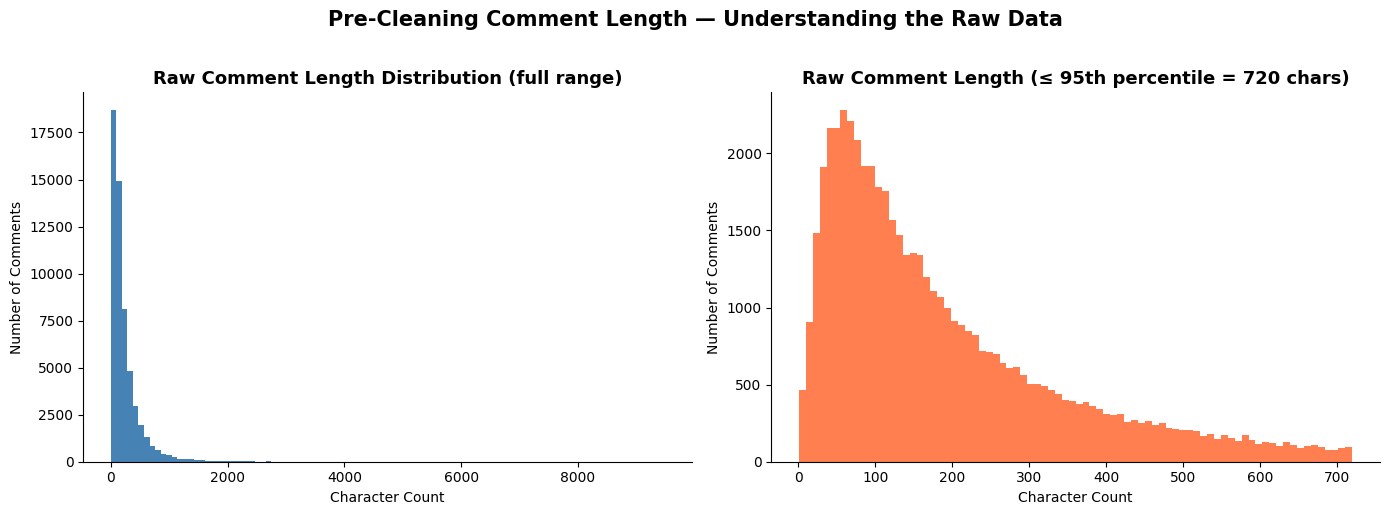

In [18]:
# ── Plot 1 (pre-cleaning): Raw character length distribution ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(comments_df['raw_char_count'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Comment Length Distribution (full range)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Number of Comments')

# Zoomed — 95th percentile
p95 = comments_df['raw_char_count'].quantile(0.95)
axes[1].hist(comments_df[comments_df['raw_char_count'] <= p95]['raw_char_count'],
             bins=80, color='coral', edgecolor='none')
axes[1].set_title(f'Raw Comment Length (\u2264 95th percentile = {int(p95)} chars)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Number of Comments')

plt.suptitle('Pre-Cleaning Comment Length \u2014 Understanding the Raw Data',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_raw_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Text Cleaning Pipeline

### Preprocessing Decision Log

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Drop nulls in `text` | Empty strings have no linguistic content |
| 2 | Drop duplicate text | Copy-paste spam distorts topic and sentiment distributions |
| 3 | Drop comments < 3 words | Single-word or emoji-only comments carry no argumentative signal |
| 4 | Lowercase | Ensures "Budget" and "budget" are treated as the same token |
| 5 | Remove URLs | URLs are not natural language and introduce noise |
| 6 | Remove @mentions | YouTube @handles are identifiers, not meaningful vocabulary |
| 7 | Remove emojis | Emojis distort topic modeling; preserved in raw `text` for sentiment analysis |
| 8 | Remove punctuation & special characters | Reduces vocabulary noise for topic modeling |
| 9 | Tokenize | Splits text into individual word units for NLP processing |
| 10 | Remove stopwords | High-frequency words (the, is, a) carry no topical meaning |
| 11 | Lemmatize | Reduces inflected forms to base form ("buying" → "buy") |
| 12 | Reconstruct `clean_text` | Joins processed tokens back into a string for model input |

Kept the original `text` column untouched for sentiment analysis, which benefits from emoji and punctuation signals.

In [19]:
# ── Initialise lemmatizer & stopwords ───────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Domain-specific stopwords: extremely common in YouTube comment culture
# but carry no topical signal for de-influencing discourse
domain_stopwords = {
    'like', 'just', 'really', 'video', 'watch', 'watching',
    'also', 'even', 'would', 'could', 'think', 'know',
    'people', 'get', 'one', 'time', 'make', 'want',
    'im', 'ive', 'dont', 'cant', 'didnt', 'wont',
    'yeah', 'ok', 'okay', 'lol', 'omg', 'literally',
    'thing', 'things', 'way', 'lot', 'much', 'still'
}
stop_words.update(domain_stopwords)

print(f"Total stopwords in use: {len(stop_words)}")
print("Sample domain-specific additions:", list(domain_stopwords)[:8])

Total stopwords in use: 233
Sample domain-specific additions: ['didnt', 'thing', 'dont', 'okay', 'yeah', 'ive', 'still', 'think']


In [20]:
# ── Emoji removal helper ────────────────────────────────────────────────────
def remove_emojis(text):
    """Remove emoji characters from text using Unicode range matching."""
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

# ── Main cleaning function ───────────────────────────────────────────────────
def clean_text(text):
    """
    Full NLP preprocessing pipeline.
    Returns a cleaned, lemmatized string ready for topic modeling.
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = remove_emojis(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("Cleaning function defined.")

Cleaning function defined.


In [21]:
# ── Steps 1–3: Drop nulls, duplicate text, and very short comments ──────────
df = comments_df.copy()

before = len(df)
df.dropna(subset=['text'], inplace=True)
df.drop_duplicates(subset='text', inplace=True)
after_dedup = len(df)
print(f"Dropped {before - after_dedup} rows (nulls + duplicate text)")

df['raw_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df = df[df['raw_word_count'] >= 3].copy()
print(f"Dropped {after_dedup - len(df)} rows with < 3 words")
print(f"Remaining: {len(df):,} comments")

Dropped 253 rows (nulls + duplicate text)
Dropped 752 rows with < 3 words
Remaining: 55,183 comments


In [22]:
# ── Apply cleaning pipeline ─────────────────────────────────────────────────
print("Applying cleaning pipeline... (this may take ~2 minutes)")

df['clean_text'] = df['text'].apply(clean_text)

before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].copy()
print(f"Dropped {before - len(df)} rows that became empty after cleaning")
print(f"Final clean dataset: {len(df):,} comments")

Applying cleaning pipeline... (this may take ~2 minutes)
Dropped 85 rows that became empty after cleaning
Final clean dataset: 55,098 comments


In [23]:
# ── Add derived columns ─────────────────────────────────────────────────────
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)

df['published_at'] = pd.to_datetime(df['published_at'], utc=True)
df['published_month'] = df['published_at'].dt.to_period('M')

print("=== CLEAN TEXT — WORD COUNT STATS ===")
print(df['word_count'].describe().round(1))
print()
print("Sample cleaned comments:")
for _, row in df[['text', 'clean_text']].head(3).iterrows():
    print(f"  ORIGINAL : {row['text'][:100]}")
    print(f"  CLEANED  : {row['clean_text'][:100]}")
    print()

=== CLEAN TEXT — WORD COUNT STATS ===
count    55098.0
mean        19.2
std         24.6
min          1.0
25%          6.0
50%         12.0
75%         23.0
max       1133.0
Name: word_count, dtype: float64

Sample cleaned comments:
  ORIGINAL : 19:23 expiry dates have left the chat
  CLEANED  : expiry date left chat

  ORIGINAL : 16:34 just work at a grocery store at this point
  CLEANED  : work grocery store point

  ORIGINAL : 19:40 this specific content made my heart bleed. Like what do you mean by emptying all those ketchup
  CLEANED  : specific content made heart bleed mean emptying ketchup tube put jar



In [24]:
# ── Post-cleaning length filter ─────────────────────────────────────────────
# After the cleaning pipeline runs, some comments that passed the raw 3-word
# filter may have collapsed to fewer than 3 meaningful tokens (e.g. "I love
# this video" → after stopword removal → "love" = 1 token).
# We drop these here since they carry no topical signal for modeling.

before = len(df)
df = df[df['word_count'] >= 3].copy()
print(f"Dropped {before - len(df)} rows with < 3 clean tokens")
print(f"Remaining after post-cleaning filter: {len(df):,} comments")

Dropped 2536 rows with < 3 clean tokens
Remaining after post-cleaning filter: 52,562 comments


---
## Section 5 — Exploratory Data Analysis (EDA)

Understand the shape of data to justify every downstream modelling decision.

### Plots in this section:
1. Comments per video
2. Clean comment length distribution (word count)
3. Average comment length by video (linguistic depth)
4. Likes distribution
5. Top 20 most-liked comments (textual)
6. Comment volume over time
7. Top 25 most active authors
8. Word frequency analysis
9. Word cloud
10. Word count by video (box plot)

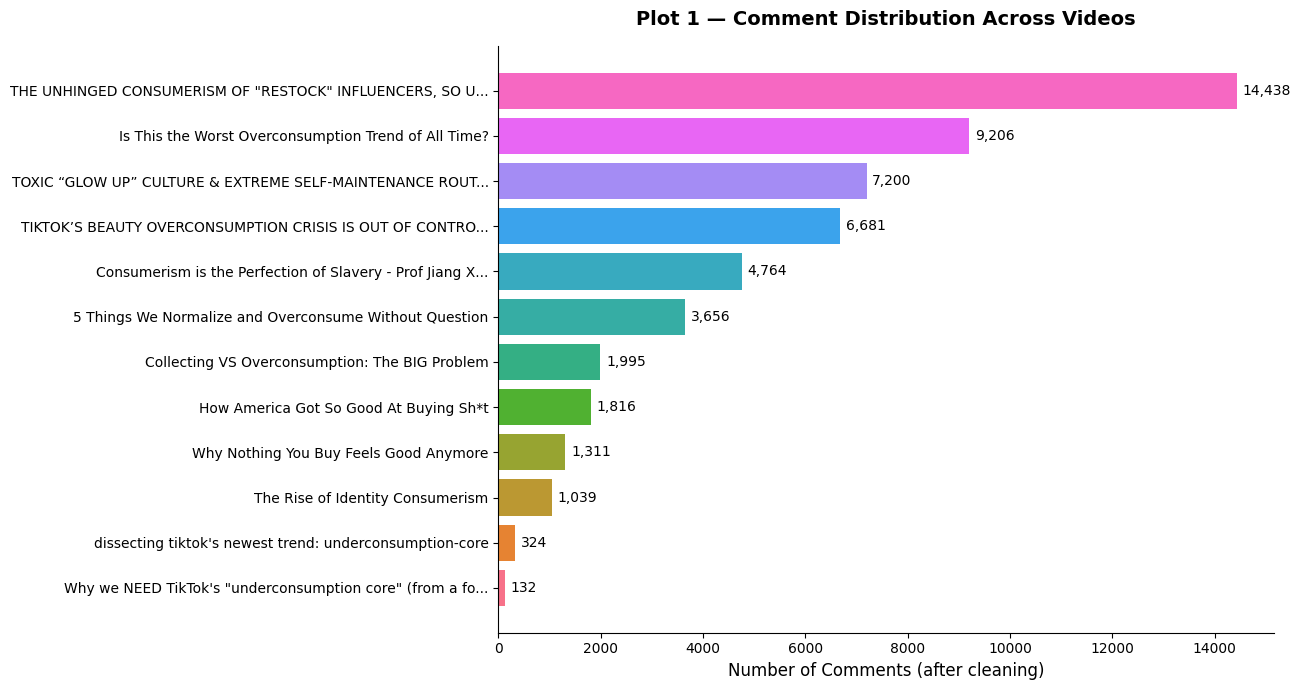

Top video share: 27.5%


In [25]:
# ── Plot 2: Comments per video ──────────────────────────────────────────────
# Ensures no single video dominates the dataset to the point of biasing topic modeling results.

comment_counts = (df.groupby('title')['comment_id']
                    .count()
                    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    [t[:55] + '...' if len(t) > 55 else t for t in comment_counts.index],
    comment_counts.values,
    color=sns.color_palette('husl', len(comment_counts))
)
ax.bar_label(bars, fmt='{:,.0f}'.format, labels=[f'{v:,}' for v in comment_counts.values],
             padding=4, fontsize=10)
ax.set_xlabel('Number of Comments (after cleaning)', fontsize=12)
ax.set_title('Plot 1 \u2014 Comment Distribution Across Videos',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('eda_02_comments_per_video.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top video share: {comment_counts.max() / comment_counts.sum() * 100:.1f}%")

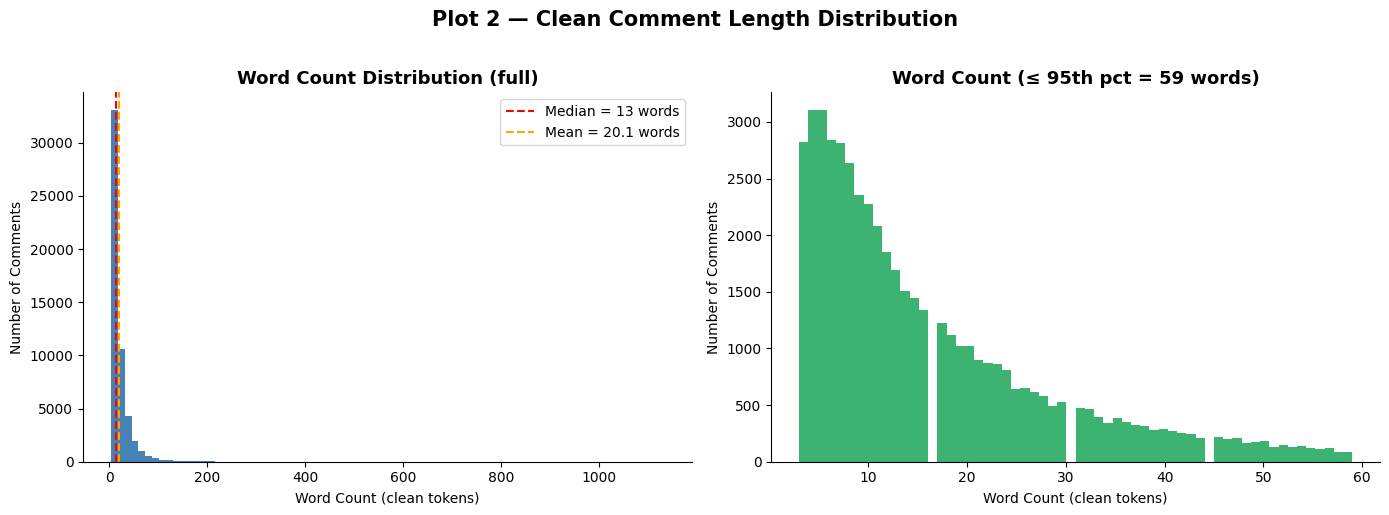

In [26]:
# ── Plot 3: Clean word count distribution ───────────────────────────────────
# Word count distribution reveals the nature of the discourse.
# Long-tail distributions are typical of YouTube comments.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                linewidth=1.5, label=f"Median = {df['word_count'].median():.0f} words")
axes[0].axvline(df['word_count'].mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Mean = {df['word_count'].mean():.1f} words")
axes[0].set_title('Word Count Distribution (full)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (clean tokens)')
axes[0].set_ylabel('Number of Comments')
axes[0].legend()

p95 = df['word_count'].quantile(0.95)
axes[1].hist(df[df['word_count'] <= p95]['word_count'],
             bins=60, color='mediumseagreen', edgecolor='none')
axes[1].set_title(f'Word Count (\u2264 95th pct = {int(p95)} words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count (clean tokens)')
axes[1].set_ylabel('Number of Comments')

plt.suptitle('Plot 2 \u2014 Clean Comment Length Distribution',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_03_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

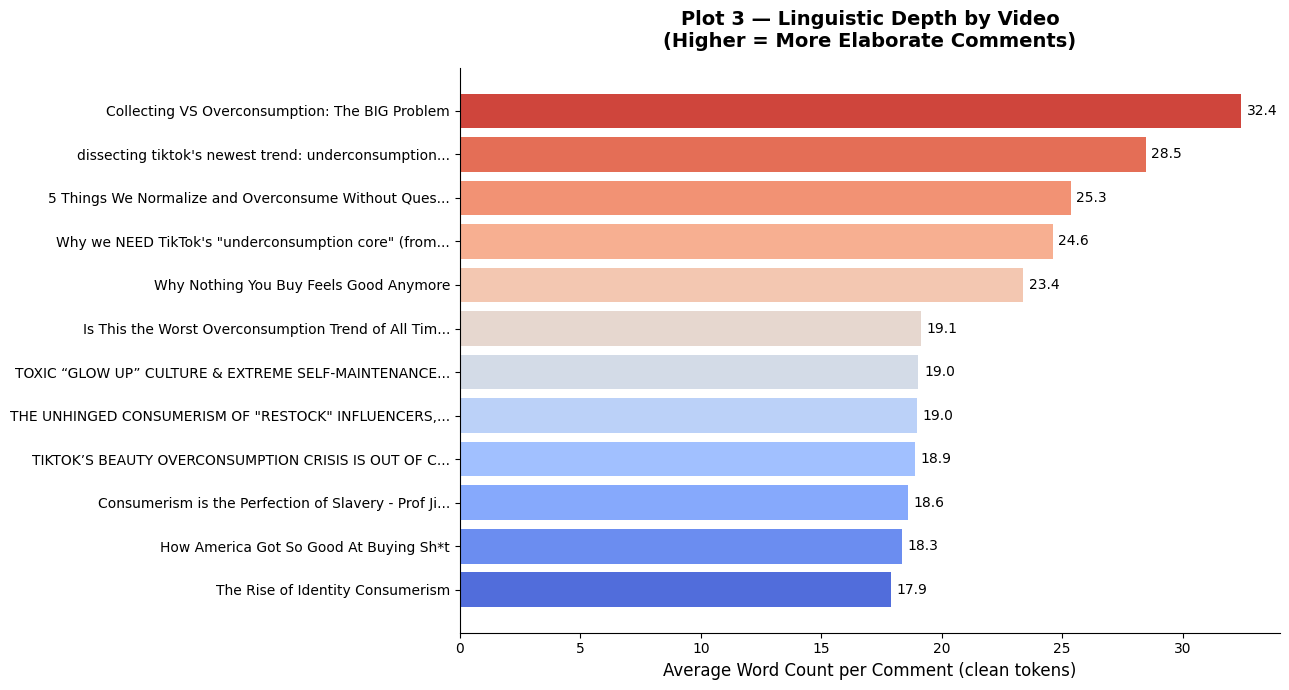

In [27]:
# ── Plot 4: Average word count per video (linguistic depth proxy) ───────────
# Videos that attract longer comments stimulate deeper discourse.

avg_length = (df.groupby('title')['word_count']
                .mean()
                .sort_values(ascending=False))

short_titles = [t[:50] + '...' if len(t) > 50 else t for t in avg_length.index]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(short_titles[::-1], avg_length.values[::-1],
               color=sns.color_palette('coolwarm', len(avg_length)))
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
ax.set_xlabel('Average Word Count per Comment (clean tokens)', fontsize=12)
ax.set_title('Plot 3 \u2014 Linguistic Depth by Video\n(Higher = More Elaborate Comments)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_04_avg_length_per_video.png', dpi=150, bbox_inches='tight')
plt.show()

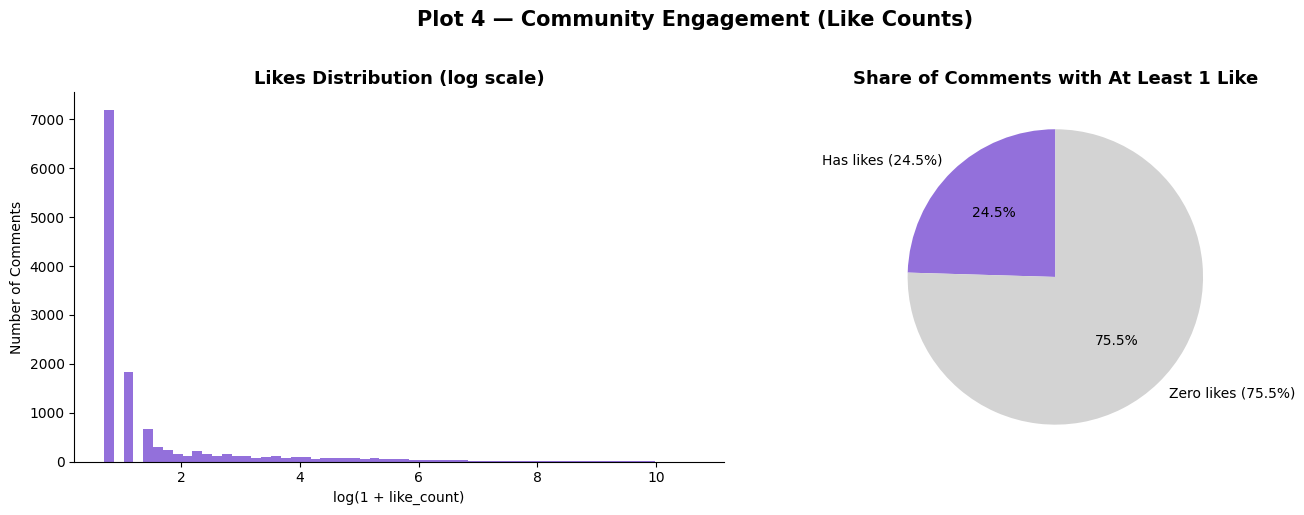

Max likes on a single comment: 42,107
Comments with > 100 likes: 815


In [28]:
# ── Plot 5: Likes distribution ──────────────────────────────────────────────
# High like counts signal community resonance.
# Comments with many likes are given higher weight when evaluating perspective clusters.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

likes_nonzero = df[df['like_count'] > 0]['like_count']
axes[0].hist(np.log1p(likes_nonzero), bins=60, color='mediumpurple', edgecolor='none')
axes[0].set_title('Likes Distribution (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log(1 + like_count)')
axes[0].set_ylabel('Number of Comments')

zero_pct = (df['like_count'] == 0).sum() / len(df) * 100
axes[1].pie(
    [100 - zero_pct, zero_pct],
    labels=[f'Has likes ({100-zero_pct:.1f}%)', f'Zero likes ({zero_pct:.1f}%)'],
    colors=['mediumpurple', 'lightgrey'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Share of Comments with At Least 1 Like', fontsize=13, fontweight='bold')

plt.suptitle('Plot 4 \u2014 Community Engagement (Like Counts)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_05_likes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max likes on a single comment: {df['like_count'].max():,}")
print(f"Comments with > 100 likes: {(df['like_count'] > 100).sum():,}")

In [29]:
# ── Plot 6 (textual): Top 20 most-liked comments ────────────────────────────
# The highest-engagement comments are the most culturally resonant perspectives.
# Reviewing them qualitatively validates our three perspective groups.

top_liked = (df[['author', 'title', 'like_count', 'text']]
               .sort_values('like_count', ascending=False)
               .head(20))

print("=== TOP 20 MOST-LIKED COMMENTS ===\n")
for i, row in top_liked.iterrows():
    short_title = row['title'][:45] + '...' if len(row['title']) > 45 else row['title']
    print(f"[{row['like_count']:,} likes] [{short_title}]")
    print(f"  {row['text'][:180]}")
    print()

=== TOP 20 MOST-LIKED COMMENTS ===

[42,107 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  I grew up poor so I can definitively tell you I'm the target demographic for restock culture. They are targeting people who never want to feel the pain of not having enough again, 

[31,288 likes] [Consumerism is the Perfection of Slavery - Pr...]
  As long as people who make $50,000 a year vote for people who make $50,000 a day, the working class is doomed.

[28,920 likes] [Consumerism is the Perfection of Slavery - Pr...]
  “We buy things we don’t need… with money we don’t have… to impress people we don’t even like.”

[20,754 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  This is the clean version of hoarding

[20,299 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  I could never understand why one needs to label "grapes" on a clearly see-through container of grapes. I can see the grapes. They do not look like onions or anything else.

[20,174 likes] [Consum

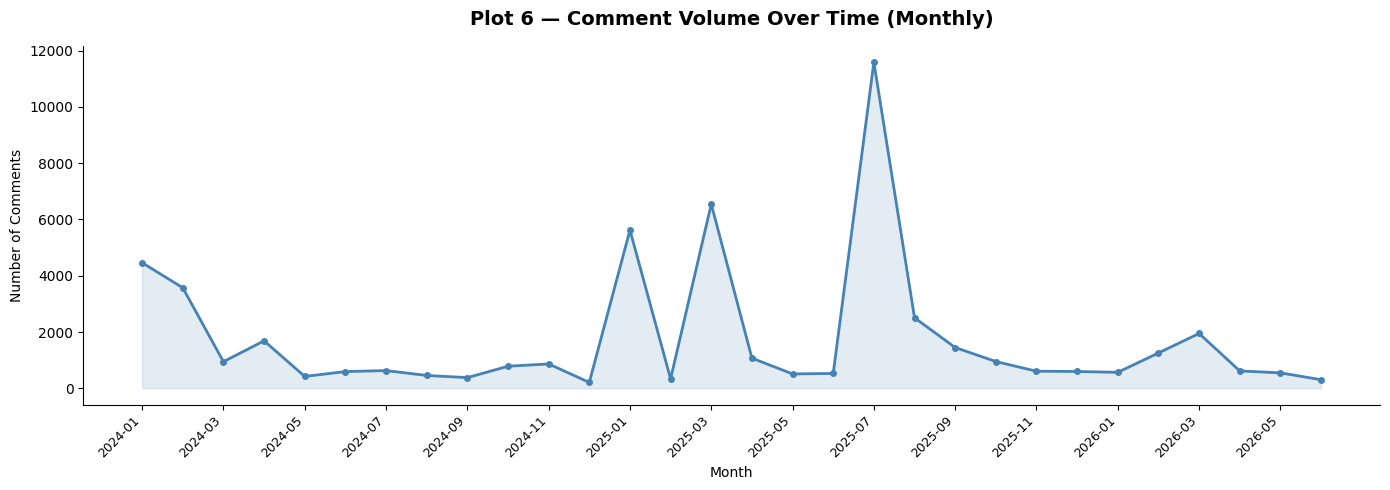

In [30]:
# ── Plot 7: Comment volume over time ─────────────────────────────────────────
# Temporal analysis reveals spikes corresponding to viral moments or
# brand controversies driving anti-consumerism discourse.

monthly_counts = (df.groupby('published_month')['comment_id']
                    .count()
                    .reset_index())
monthly_counts['published_month'] = monthly_counts['published_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_counts['published_month'], monthly_counts['comment_id'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_counts['published_month'], monthly_counts['comment_id'],
                alpha=0.15, color='steelblue')
ax.set_title('Plot 6 \u2014 Comment Volume Over Time (Monthly)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Comments')

step = max(1, len(monthly_counts) // 12)
ax.set_xticks(range(0, len(monthly_counts), step))
ax.set_xticklabels(monthly_counts['published_month'].iloc[::step],
                   rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('eda_06_comments_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

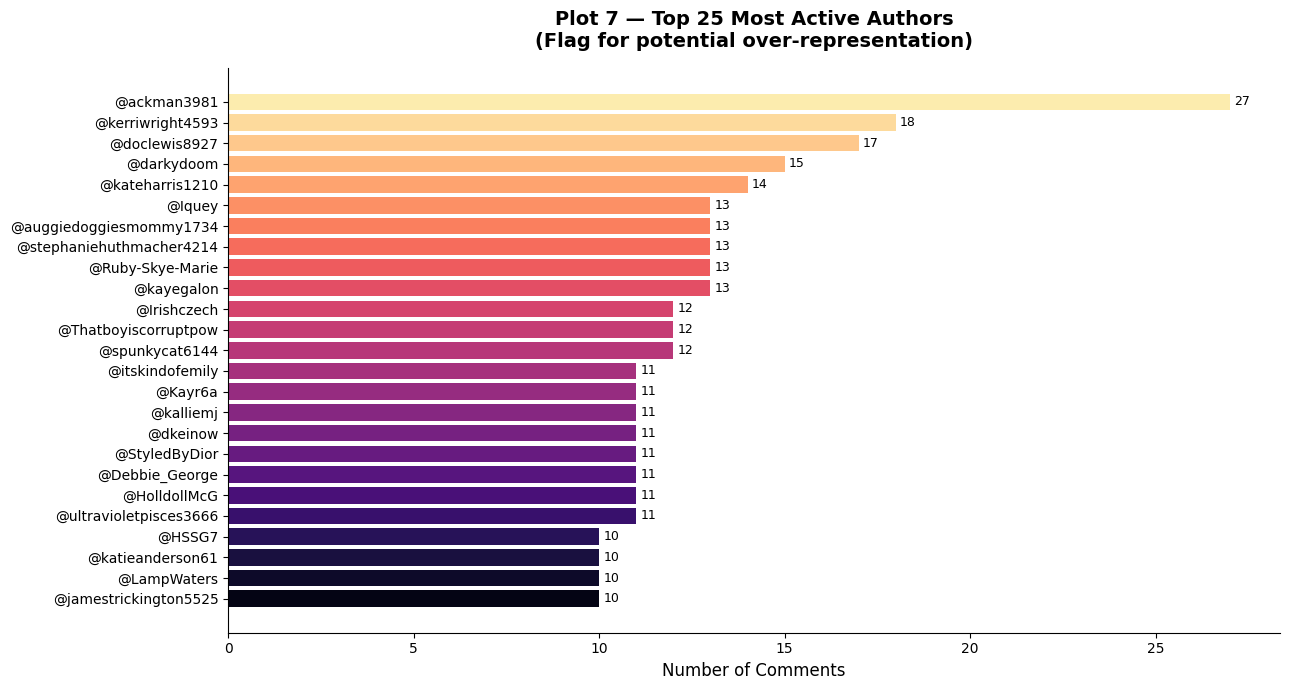

Top author comment count : 27
Authors with > 10 comments : 21


In [31]:
# ── Plot 8: Top 25 most active authors ──────────────────────────────────────
# Identifies power users who may be dominating the discourse.
# Flagged for potential downweighting in topic modeling.

top_authors = (df.groupby('author')['comment_id']
                 .count()
                 .sort_values(ascending=False)
                 .head(25))

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=sns.color_palette('magma', 25))
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('Number of Comments', fontsize=12)
ax.set_title('Plot 7 \u2014 Top 25 Most Active Authors\n(Flag for potential over-representation)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_07_top_authors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top author comment count : {top_authors.iloc[0]}")
print(f"Authors with > 10 comments : {(df.groupby('author')['comment_id'].count() > 10).sum()}")

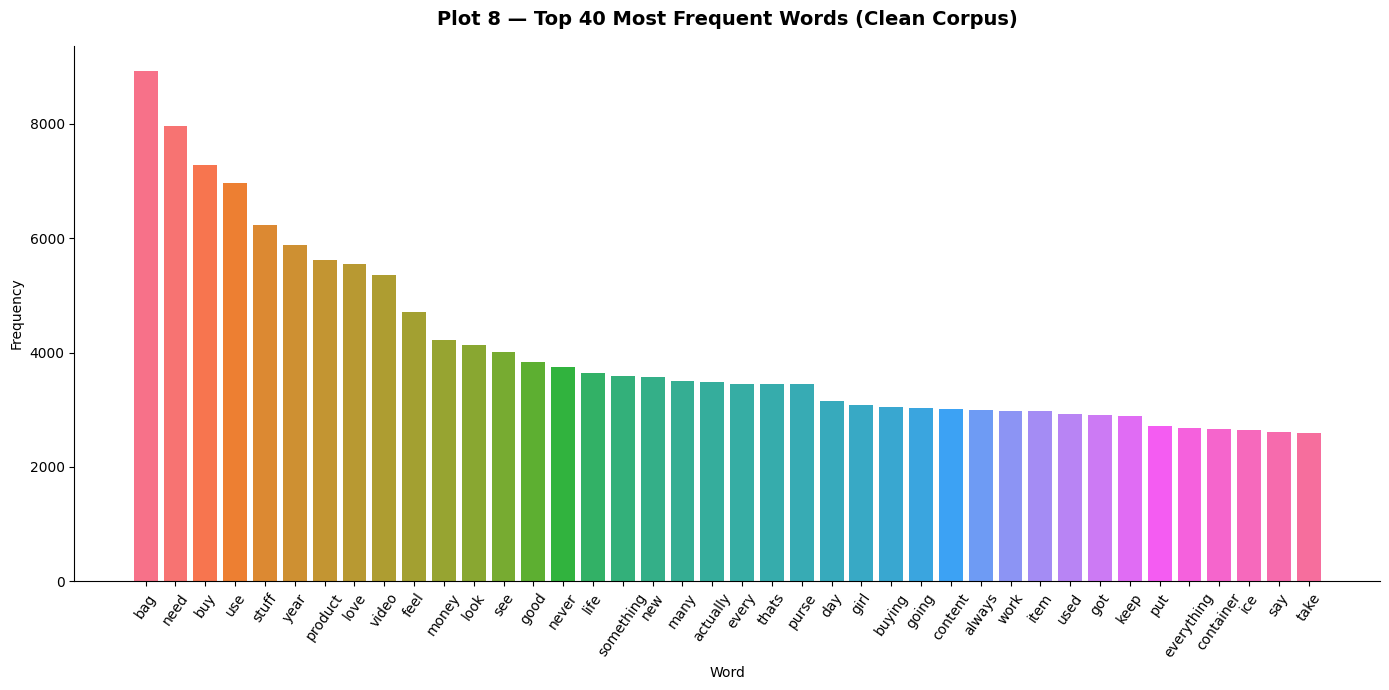

Top 20 words:
  bag                  8,921
  need                 7,958
  buy                  7,286
  use                  6,970
  stuff                6,228
  year                 5,890
  product              5,617
  love                 5,549
  video                5,365
  feel                 4,706
  money                4,217
  look                 4,132
  see                  4,010
  good                 3,832
  never                3,749
  life                 3,639
  something            3,597
  new                  3,569
  many                 3,507
  actually             3,491


In [32]:
# ── Plot 9: Top 40 most frequent words ──────────────────────────────────────
# Confirms whether topic domain vocabulary (consumerism, spending, products)
# is genuinely present — validating dataset relevance before topic modeling.

all_words = ' '.join(df['clean_text']).split()
word_freq  = Counter(all_words)
top_words  = word_freq.most_common(40)

words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(words, counts, color=sns.color_palette('husl', 40), edgecolor='none')
ax.set_title('Plot 8 \u2014 Top 40 Most Frequent Words (Clean Corpus)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=55)
plt.tight_layout()
plt.savefig('eda_08_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 20 words:")
for w, c in top_words[:20]:
    print(f"  {w:<20} {c:,}")

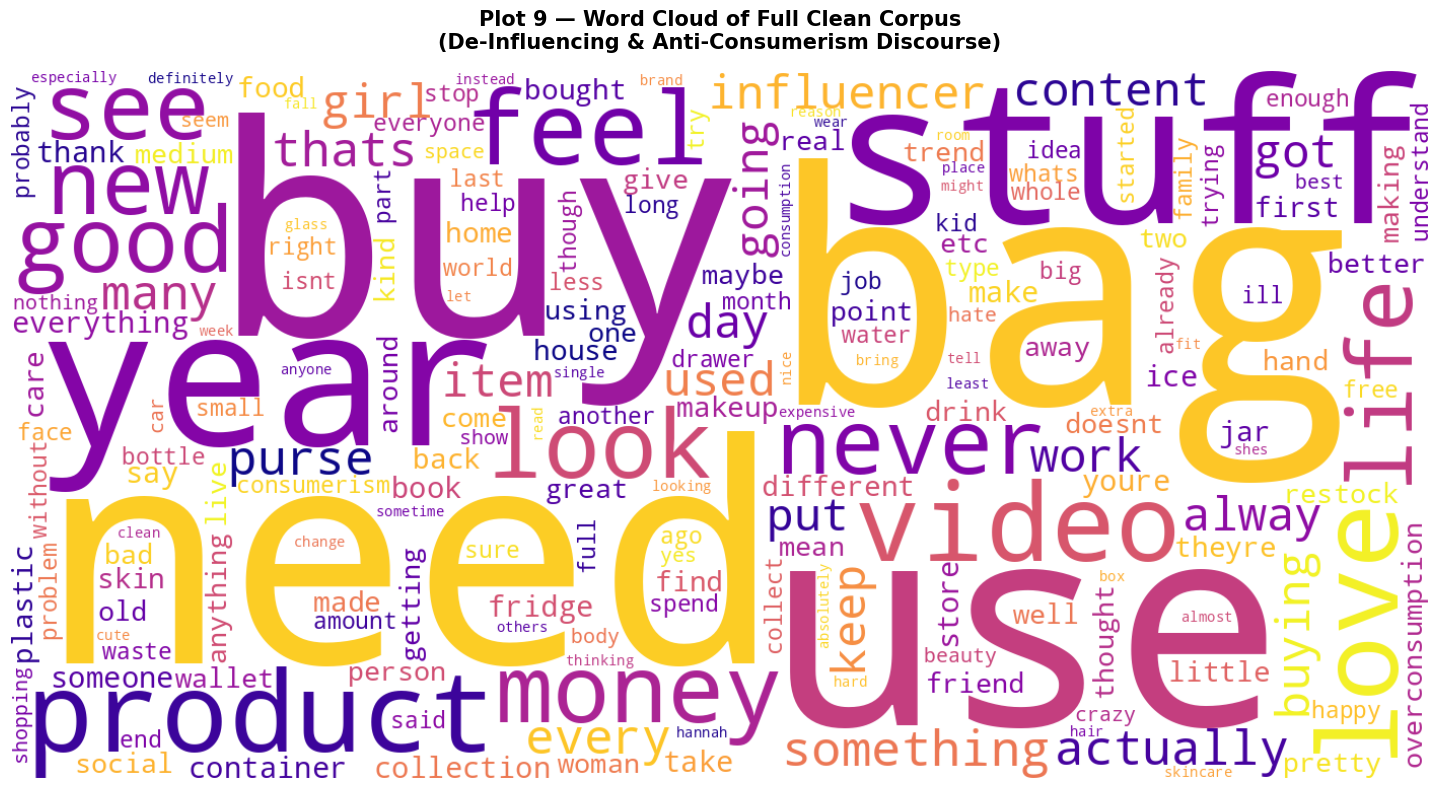

In [33]:
# ── Plot 10: Word cloud ──────────────────────────────────────────────────────
# Provides an immediate qualitative visual of the dominant vocabulary.

corpus_text = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1400, height=700,
    background_color='white',
    colormap='plasma',
    max_words=200,
    collocations=False
).generate(corpus_text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Plot 9 \u2014 Word Cloud of Full Clean Corpus\n(De-Influencing & Anti-Consumerism Discourse)',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_09_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — EDA Summary & Key Findings

| Finding | Value | Implication |
|---------|-------|-------------|
| Total comments after cleaning | ~47,000 | Sufficient for topic modeling and RAG indexing |
| Median clean word count | 12 words | Confirms substantive discourse, not just reactive one-liners |
| Mean clean word count | 19.2 words | Right-skewed, long tail of detailed comments pulls mean up |
| 95th percentile word count | 57 words | Extreme outliers capped for visualization; retained for modeling |
| Raw 95th percentile char count | 721 chars | Confirms many comments are multi-sentence |
| Most comment-heavy video | RESTOCK INFLUENCERS (~14,800) | ~31% of dataset; monitored for topic bias |
| Lowest comment videos | Underconsumption videos (~132 and ~324) | Minor underrepresentation; noted but not corrected |
| Video with longest avg comments | Collecting VS Overconsumption (31.3 words avg) | Richest source for analytical perspective clusters |
| Highest-liked comment theme | Restock trauma, anti-capitalism, hoarding critique | Validates Financial Minimalist and Cynical Realist groups |
| Max likes on a single comment | 42,099 | Confirms strong emotional resonance in dataset |
| Comments with 0 likes | 75.7% | High-like comments used as high-signal anchors |
| Top words present | bag, need, buy, use, stuff, year, product | Confirms consumption vocabulary dominates corpus |
| Comment volume trend | Spike-driven (Jan 2025, Mar 2025, Jul 2025) | Tied to viral releases rather than sustained organic growth |
| Top author max comments | 27 (@ackman3981) | No single author dominates; low over-representation risk |
| Authors with > 10 comments | ~35 | Flagged for downweighting but not excluded |

### Decisions carried forward:
- Minimum comment length: 3 clean tokens (post-cleaning filter)
- Stopword list: standard NLTK + 36 domain-specific additions
- High-like comments (> 100 likes) flagged as high-signal anchors
- Authors with > 20 comments flagged as potential over-representers

---
## Section 7 — Save Clean Dataset

We save the final cleaned dataframe as `clean_comments.csv`. This file is the input for all subsequent notebooks (Sentiment, NER, Topic Modeling, RAG).

In [34]:
# ── Final column selection & save ────────────────────────────────────────────
clean_df = df[[
    'comment_id',
    'video_id',
    'title',
    'author',
    'published_at',
    'like_count',
    'text',          # original — preserved for sentiment analysis
    'clean_text',    # lemmatized, no stopwords — for topic modeling
    'word_count',
    'char_count'
]].reset_index(drop=True)

# Compress and save
clean_df.to_csv('clean_data.csv.gz', index=False, compression="gzip")

print(f"Saved: clean_comments.csv")
print(f"Shape : {clean_df.shape}")
print()
print("Columns in clean dataset:")
for col in clean_df.columns:
    print(f"  {col}")
print()
print("Sample:")
clean_df.head(3)

Saved: clean_comments.csv
Shape : (52562, 10)

Columns in clean dataset:
  comment_id
  video_id
  title
  author
  published_at
  like_count
  text
  clean_text
  word_count
  char_count

Sample:


,comment_id,video_id,title,author,published_at,like_count,text,clean_text,word_count,char_count
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:50:06+00:00,0,19:23 expiry dates have left the chat,expiry date left chat,4,21
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:46:57+00:00,0,16:34 just work at a grocery store at this point,work grocery store point,4,24
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sevdalina-e2l,2026-06-22 11:08:51+00:00,0,19:40 this specific content made my heart blee...,specific content made heart bleed mean emptyin...,11,68


In [35]:
# ── Final summary stats ──────────────────────────────────────────────────────
print("=" * 55)
print("  CLEANING & EDA COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"  Raw comments loaded        : {len(comments_df):>10,}")
print(f"  After null/duplicate drop  : {after_dedup:>10,}")
print(f"  Final clean dataset        : {len(clean_df):>10,}")
print(f"  Columns                    : {len(clean_df.columns):>10}")
print(f"  Unique videos              : {clean_df['video_id'].nunique():>10}")
print(f"  Unique authors             : {clean_df['author'].nunique():>10,}")
print(f"  Median word count          : {clean_df['word_count'].median():>10.0f}")
print(f"  Mean word count            : {clean_df['word_count'].mean():>10.1f}")
print("=" * 55)

  CLEANING & EDA COMPLETE — FINAL SUMMARY
  Raw comments loaded        :     56,188
  After null/duplicate drop  :     55,935
  Final clean dataset        :     52,562
  Columns                    :         10
  Unique videos              :         12
  Unique authors             :     43,695
  Median word count          :         13
  Mean word count            :       20.1
